# So sánh các model phân loại ký hiệu tay (Hand Sign Classification)

Notebook này:
1. Đọc dữ liệu keypoint đã trích xuất + augment (`keypoints_augmented.csv`)
2. Train & đánh giá 5 model bằng cross-validation: Random Forest, Gradient Boosting, SVM (RBF), MLP, k-NN
3. Vẽ biểu đồ so sánh accuracy giữa các model
4. Chọn model tốt nhất, vẽ confusion matrix để xem chi tiết model nhầm ở đâu
5. Lưu model tốt nhất ra `model.pkl` để dùng với `inference_webcam.py`


In [1]:
# Cài đặt (chạy 1 lần nếu chưa có)
# !pip install pandas scikit-learn matplotlib seaborn joblib


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier

sns.set_theme(style="whitegrid")
SEED = 42


## 1. Load dữ liệu

In [3]:
RAW_CSV_PATH = "/content/keypoints.csv"                  # dữ liệu GỐC, chưa augment
AUGMENTED_CSV_PATH = "/content/keypoints_augmented.csv"   # dữ liệu gốc + augmented (có cột sample_id, is_original)

df_raw = pd.read_csv(RAW_CSV_PATH)
df_aug = pd.read_csv(AUGMENTED_CSV_PATH)

print(f"Dữ liệu gốc: {len(df_raw)} mẫu, {df_raw['label'].nunique()} lớp")
print(f"Dữ liệu sau augment: {len(df_aug)} mẫu")
df_raw['label'].value_counts().sort_index()


Dữ liệu gốc: 3739 mẫu, 24 lớp
Dữ liệu sau augment: 22434 mẫu


,count
label,
a,243
b,243
c,228
d,202
e,227
f,232
g,231
h,223
i,208


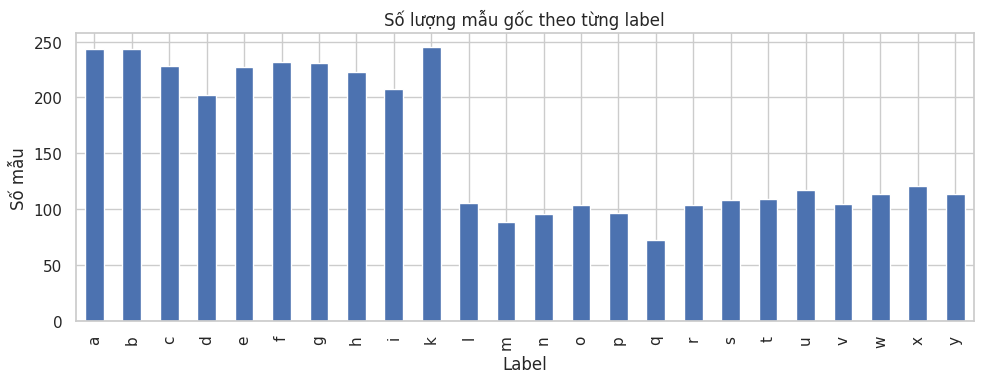

In [4]:
# Biểu đồ phân bố số mẫu theo từng label (trên dữ liệu GỐC, chưa augment) — kiểm tra imbalance
plt.figure(figsize=(10, 4))
df_raw['label'].astype(str).value_counts().sort_index().plot(kind='bar', color='#4C72B0')
plt.title("Số lượng mẫu gốc theo từng label")
plt.xlabel("Label")
plt.ylabel("Số mẫu")
plt.tight_layout()
plt.show()


In [5]:
# BƯỚC 1: split sample_id GỐC thành train/test trước (chưa đụng đến augmented data)
train_ids, test_ids = train_test_split(
    df_raw["sample_id"].values,
    test_size=0.2,
    random_state=SEED,
    stratify=df_raw["label"].values,
)
print(f"Số ảnh gốc dùng để train: {len(train_ids)} | dùng để test (giữ nguyên, không augment): {len(test_ids)}")


Số ảnh gốc dùng để train: 2991 | dùng để test (giữ nguyên, không augment): 748


In [6]:
# BƯỚC 2: xây tập TRAIN = toàn bộ bản gốc + augmented có sample_id thuộc train_ids
train_pool = df_aug[df_aug["sample_id"].isin(train_ids)].reset_index(drop=True)

# BƯỚC 3: xây tập TEST = CHỈ lấy từ df_raw (ảnh gốc, chưa augment) có sample_id thuộc test_ids
#          KHÔNG lấy từ df_aug để đảm bảo test không dính bất kỳ bản augmented nào
test_pool = df_raw[df_raw["sample_id"].isin(test_ids)].reset_index(drop=True)

print(f"Train pool (gốc + augmented): {len(train_pool)} mẫu")
print(f"Test pool (CHỈ ảnh gốc, chưa từng augment): {len(test_pool)} mẫu")

feature_cols = [c for c in df_raw.columns if c not in ("sample_id", "label")]

le = LabelEncoder()
le.fit(df_raw["label"].values)  # fit trên toàn bộ label gốc để đảm bảo đủ lớp

X_train = train_pool[feature_cols].values
y_train = le.transform(train_pool["label"].values)
groups_train = train_pool["sample_id"].values  # dùng cho GroupKFold bên dưới

X_test = test_pool[feature_cols].values
y_test = le.transform(test_pool["label"].values)


Train pool (gốc + augmented): 17946 mẫu
Test pool (CHỈ ảnh gốc, chưa từng augment): 748 mẫu


## 2. Định nghĩa các model muốn so sánh

In [7]:
candidates = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=100, random_state=SEED),  # nhanh hơn nhiều so với GradientBoostingClassifier với multiclass
    "SVM_RBF": make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", C=10, gamma="scale", probability=False, random_state=SEED),  # probability=False -> nhanh hơn nhiều
    ),
    "MLP": make_pipeline(
        StandardScaler(),
        MLPClassifier(
            hidden_layer_sizes=(128, 64), activation="relu",
            max_iter=300, early_stopping=True, n_iter_no_change=10,
            random_state=SEED,
        ),
    ),
    "kNN": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=5),
    ),
}


## 3. Cross-validation cho từng model

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {}
for name, model in candidates.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:>18}: mean = {scores.mean():.4f}  std = {scores.std():.4f}")

results_df = pd.DataFrame(cv_results)
results_df


      RandomForest: mean = 0.9865  std = 0.0022
HistGradientBoosting: mean = 0.9882  std = 0.0014
           SVM_RBF: mean = 0.9933  std = 0.0006
               MLP: mean = 0.9943  std = 0.0016
               kNN: mean = 0.9617  std = 0.0046


,RandomForest,HistGradientBoosting,SVM_RBF,MLP,kNN
0,0.984401,0.986630,0.992479,0.993036,0.959331
1,0.985511,0.989691,0.993592,0.996099,0.955977
2,0.986904,0.987183,0.993313,0.992198,0.959042
3,0.990527,0.987462,0.992756,0.996099,0.968794
4,0.985233,0.989969,0.994149,0.994149,0.965171


## 4. Trực quan hoá kết quả so sánh

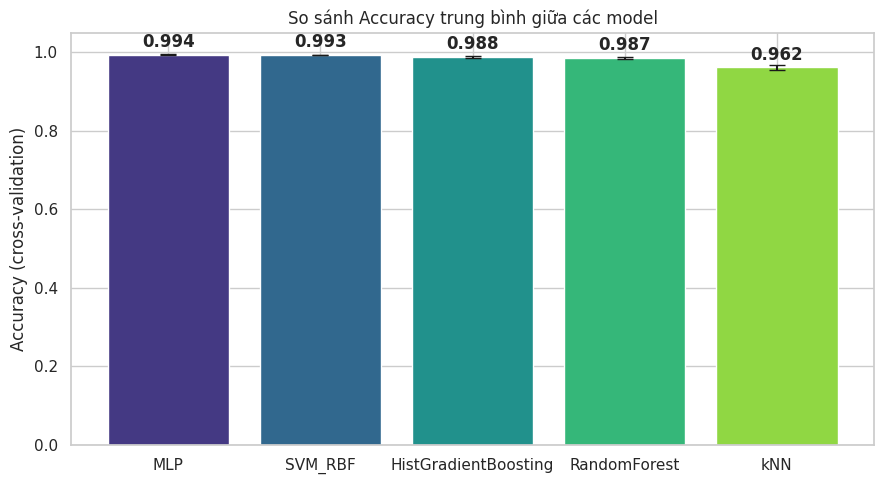

In [9]:
# Biểu đồ cột: accuracy trung bình ± độ lệch chuẩn của từng model
means = results_df.mean().sort_values(ascending=False)
stds = results_df.std()[means.index]

plt.figure(figsize=(9, 5))
bars = plt.bar(means.index, means.values, yerr=stds.values, capsize=6,
               color=sns.color_palette("viridis", len(means)))
plt.ylabel("Accuracy (cross-validation)")
plt.title("So sánh Accuracy trung bình giữa các model")
plt.ylim(0, 1.05)
for bar, val in zip(bars, means.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}",
              ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


/tmp/ipykernel_4058/1661854845.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="Model", y="Accuracy", palette="viridis")


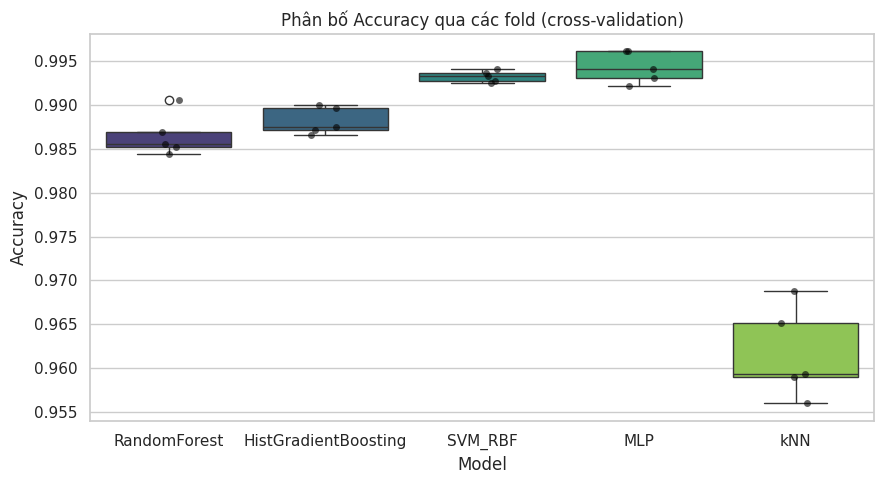

In [10]:
# Boxplot: phân bố accuracy qua từng fold — model nào ổn định hơn (box hẹp = ổn định)
plt.figure(figsize=(9, 5))
melted = results_df.melt(var_name="Model", value_name="Accuracy")
sns.boxplot(data=melted, x="Model", y="Accuracy", palette="viridis")
sns.stripplot(data=melted, x="Model", y="Accuracy", color="black", alpha=0.6, jitter=True)
plt.title("Phân bố Accuracy qua các fold (cross-validation)")
plt.tight_layout()
plt.show()


## 5. Chọn model tốt nhất, đánh giá chi tiết trên tập test

In [15]:
best_name = means.index[0]
print(f"Model tốt nhất theo cross-validation: {best_name}")

best_model = candidates[best_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("\n=== Classification report trên tập test (giữ riêng, chưa train) ===")
print(classification_report(y_test, y_pred, target_names=le.classes_.astype(str)))


Model tốt nhất theo cross-validation: MLP

=== Classification report trên tập test (giữ riêng, chưa train) ===
              precision    recall  f1-score   support

           a       0.98      1.00      0.99        49
           b       0.98      1.00      0.99        49
           c       1.00      0.98      0.99        46
           d       1.00      1.00      1.00        40
           e       0.98      1.00      0.99        45
           f       1.00      0.98      0.99        46
           g       1.00      1.00      1.00        46
           h       0.96      1.00      0.98        45
           i       1.00      0.98      0.99        42
           k       1.00      1.00      1.00        49
           l       1.00      0.95      0.98        21
           m       0.94      0.94      0.94        18
           n       0.94      0.89      0.92        19
           o       0.95      1.00      0.98        21
           p       1.00      0.95      0.97        19
           q       1.00 

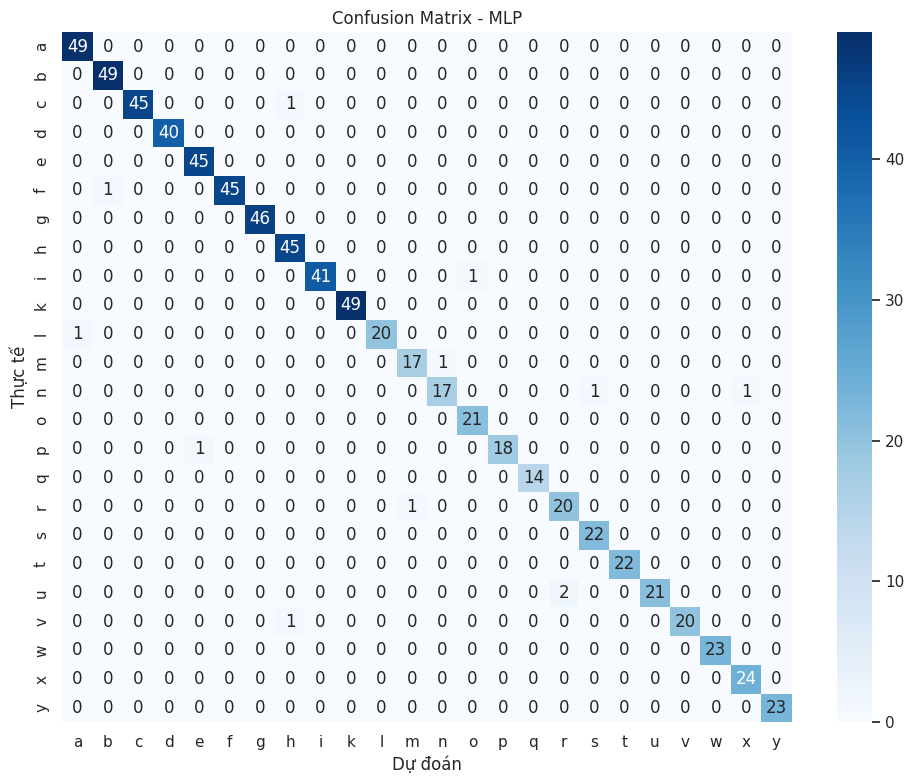

In [16]:
# Confusion matrix dạng heatmap — xem model hay nhầm label nào với label nào
cm = confusion_matrix(y_test, y_pred)
labels_str = le.classes_.astype(str)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_str, yticklabels=labels_str, cbar=True)
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
plt.show()


## 6. Train lại trên toàn bộ dữ liệu & lưu model

In [17]:
final_model = best_model  # đã đúng cấu hình probability=True nếu là SVM (từ cell trên)

# Giờ đánh giá xong rồi, train lại trên TOÀN BỘ dữ liệu có (gốc + augmented,
# cả phần trước đó giữ làm test) để tận dụng hết data cho model dùng thực tế
X_full = df_aug[feature_cols].values
y_full = le.transform(df_aug["label"].values)
final_model.fit(X_full, y_full)

joblib.dump(
    {"model": final_model, "label_encoder": le, "model_name": best_name},
    "model.pkl"
)
print(f"Đã lưu model '{best_name}' vào model.pkl — sẵn sàng dùng với inference_webcam.py")


Đã lưu model 'MLP' vào model.pkl — sẵn sàng dùng với inference_webcam.py
